In [1]:
import os
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
import torch
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from typing import Tuple
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import torch.nn.functional as F

In [2]:
# Проверяем наличие CUDA
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Используется GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("CUDA не найдена, используется CPU")

Используется GPU: NVIDIA GeForce RTX 3060


In [ ]:
class FaceDataset(Dataset):
    def __init__(self, root_dir, transform=None, pairs_count=10000, pos_ratio=0.5, is_train=True):
        super().__init__()
        self.root_dir = root_dir
        self.transform = transform
        self.pairs_count = pairs_count
        self.pos_ratio = pos_ratio
        self.is_train = is_train

        self.identity_images = {}
        self.identities = []
        self.pairs = []

        for identity in os.listdir(root_dir):
            identity_path = os.path.join(root_dir, identity)
            if os.path.isdir(identity_path):
                img_files = [f for f in os.listdir(identity_path) if f.endswith('.pgm')]
                img_files.sort()
                
                if len(img_files) > 0:
                    if is_train:
                        identity_imgs = [os.path.join(identity_path, f) for f in img_files[:8]]
                    else:
                        identity_imgs = [os.path.join(identity_path, f) for f in img_files[8:]]
                    
                    if len(identity_imgs) > 0:
                        self.identity_images[identity] = identity_imgs
                        self.identities.append(identity)

        for _ in range(pairs_count):
            is_positive = random.random() < self.pos_ratio
            
            id1 = random.choice(self.identities)
            img1_path = random.choice(self.identity_images[id1])
            
            label = 1.0
            
            if is_positive:
                if len(self.identity_images[id1]) > 1:
                    available_imgs = [p for p in self.identity_images[id1] if p != img1_path]
                    if available_imgs:
                        img2_path = random.choice(available_imgs)
                    else:
                        is_positive = False
                else:
                    is_positive = False
            
            if not is_positive:
                other_identities = [i for i in self.identities if i != id1]
                if other_identities:
                    id2 = random.choice(other_identities)
                    img2_path = random.choice(self.identity_images[id2])
                    label = 0.0
                else:
                    img2_path = img1_path 
                    label = 0.0 

            self.pairs.append((img1_path, img2_path, label))

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]

        img1 = Image.open(img1_path)
        img2 = Image.open(img2_path)

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)
        
        return img1, img2, torch.tensor(label, dtype=torch.float32)
    
    def __len__(self):
        return len(self.pairs)

In [ ]:

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


train_dataset = FaceDataset(root_dir='archive', transform=train_transform)
val_dataset = FaceDataset(root_dir='archive', transform=val_transform, pairs_count=2000, is_train=False)
tsne_dataset = datasets.ImageFolder(root='archive', transform=val_transform)


train_loader = DataLoader(dataset=train_dataset, batch_size=256, shuffle=True, pin_memory=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=256, shuffle=False, pin_memory=True)
tsne_loader = DataLoader(dataset=tsne_dataset, batch_size=256, shuffle=False, pin_memory=True)



In [ ]:
class SiamNetModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.seq = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), 
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), 
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1), 
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
        )
        
    def forward(self, x1, x2):
        emb1 = self.seq(x1)
        emb2 = self.seq(x2)
        emb1 = F.normalize(emb1, p=2, dim=1)
        emb2 = F.normalize(emb2, p=2, dim=1)
        return emb1, emb2

In [6]:
criterion = nn.BCELoss()
model =  SiamNetModel().to(device)
opt = optim.Adam(model.parameters(), lr=0.0001)

def train_step() -> float:
    model.train()
    
    running_loss = 0.
    for img1, img2, labels in train_loader:
        img1 = img1.to(device)
        img2 = img2.to(device)
        labels = labels.to(device)
        
        opt.zero_grad()
        

        emb1, emb2 = model(img1, img2)

        distance = F.pairwise_distance(emb1, emb2)

        probs = 1 / (1 + distance)
        probs = torch.clamp(probs, 1e-7, 1 - 1e-7)
        
        loss = criterion(probs, labels)

        loss.backward()

        opt.step()
        
        running_loss += loss
    
    # Контекстный менеджер `torch.no_grad` позволяет отключить вычисление градиентов.
    # Вычисления, в которые входят обучаемые параметры, не имеющие отношения к сети повлияют на процесс обучения,
    # если для них будут накапливаться градиенты.
    # Экономия памяти.
    with torch.no_grad():
        train_loss = running_loss / len(train_loader)
    return train_loss.item()


def val_step() -> Tuple[float, float]:
    model.eval()

    correct_total = 0.
    running_loss = 0.

    with torch.no_grad():
        for img1,  img2, labels in val_loader:
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.to(device)

            emb1, emb2 = model(img1, img2)


            distance = F.pairwise_distance(emb1, emb2)
            probs = 1 / (1 + distance)
            probs = torch.clamp(probs, 1e-7, 1 - 1e-7)

            
            loss = criterion(probs, labels)
            running_loss += loss

            predictions = (probs > 0.5).float()
            correct_total += (predictions == labels).sum()
        
    valid_loss = running_loss / len(val_loader)
    accuracy = correct_total / len(val_loader.dataset)
    return valid_loss.item(), accuracy.item()

In [7]:
train_losses = []
valid_losses = []
valid_accs = []

In [8]:
epochs = 20
model.to(device)

for _ in (pbar := tqdm(range(epochs))):
    train_loss = train_step()
    valid_loss, valid_acc = val_step()
    
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)
    
    pbar.set_description(f'Avg. train/valid loss/valid acc: {train_loss:.4f}/{valid_loss:.4f}/{valid_acc:.4f}')

Avg. train/valid loss/valid acc: 0.3301/0.3369/0.9205: 100%|██████████| 20/20 [02:43<00:00,  8.18s/it]


Text(0, 0.5, 'Loss')

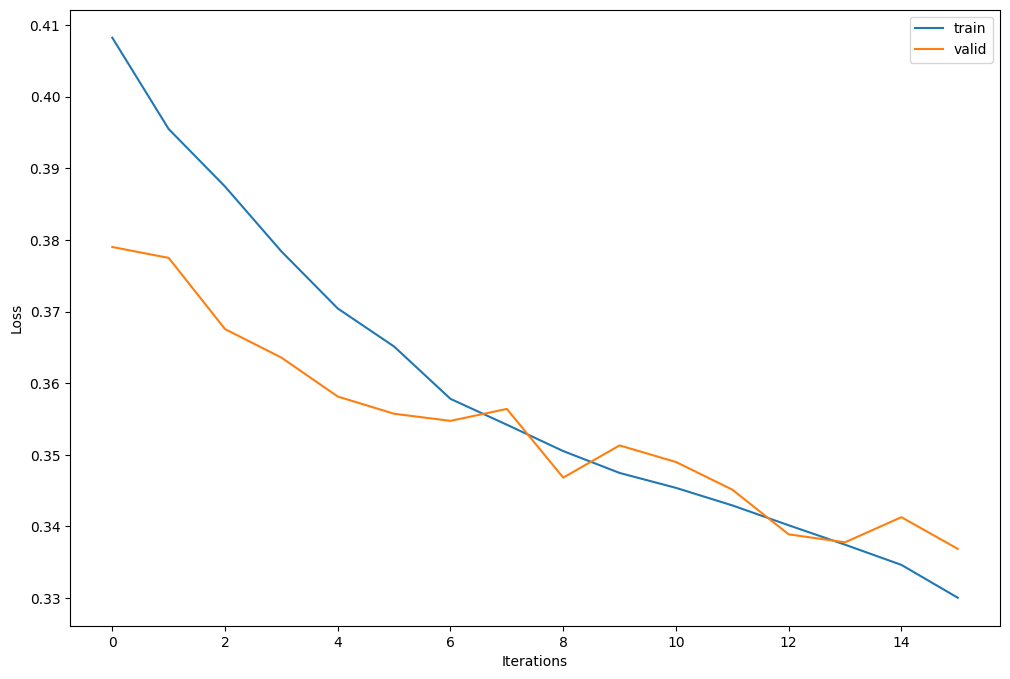

In [9]:
fig = plt.figure(figsize=(12, 8))

plt.plot(train_losses[4:], label='train')
plt.plot(valid_losses[4:], label='valid')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')

Text(0, 0.5, 'Accuracy')

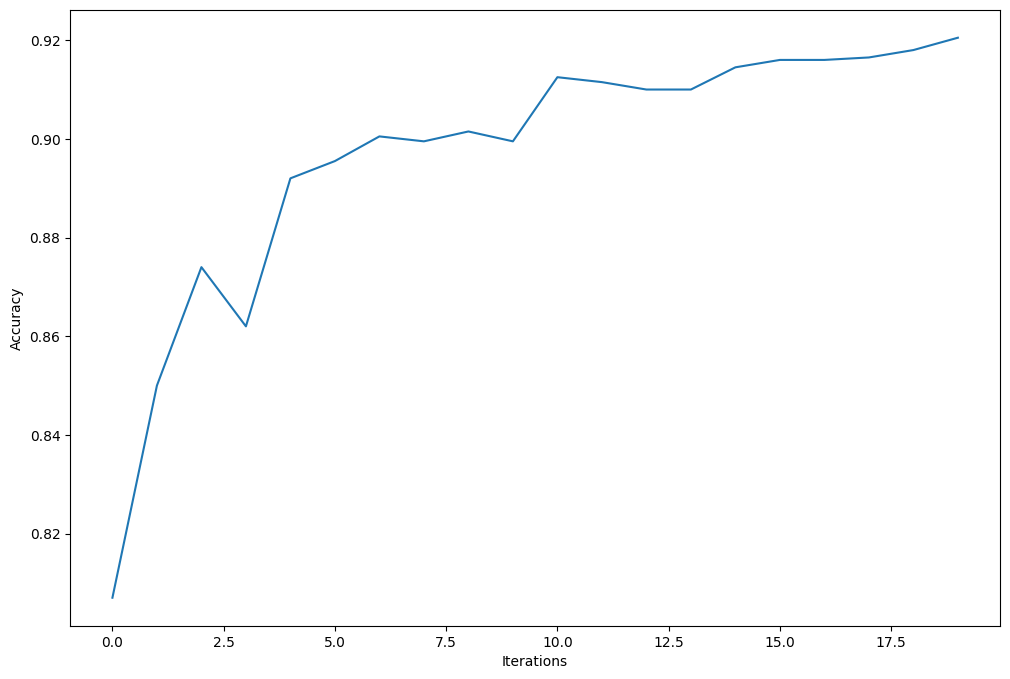

In [10]:
fig = plt.figure(figsize=(12, 8))

plt.plot(valid_accs)
plt.xlabel('Iterations')
plt.ylabel('Accuracy')

In [11]:
import matplotlib.pyplot as plt

def visualize_pairs(val_loader, model, device, num_pairs=8, threshold=0.5):

    model.eval()
    
    img1_batch, img2_batch, labels_batch = next(iter(val_loader))
    
    num_pairs = min(num_pairs, len(img1_batch))
    
    img1_batch = img1_batch[:num_pairs].to(device)
    img2_batch = img2_batch[:num_pairs].to(device)
    labels_batch = labels_batch[:num_pairs].to(device)
    
    with torch.no_grad():
        emb1, emb2 = model(img1_batch, img2_batch)
        
        distance = F.pairwise_distance(emb1, emb2)
        probs = torch.exp(-distance)
        
        predictions = (probs > threshold).float()
    
    fig, axes = plt.subplots(num_pairs, 2, figsize=(10, 5 * num_pairs))
    
    if num_pairs == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(num_pairs):
        img1 = img1_batch[i].cpu().permute(1, 2, 0).numpy()
        img2 = img2_batch[i].cpu().permute(1, 2, 0).numpy()
        
        if img1.shape[2] == 1:
            img1 = img1.squeeze()
            img2 = img2.squeeze()
        
        true_label = labels_batch[i].item()
        pred_label = predictions[i].item()
        prob_value = probs[i].item()
        
        is_correct = (true_label == pred_label)
        color = 'green' if is_correct else 'red'
        status = '✓' if is_correct else '✗'
        
        axes[i, 0].imshow(img1, cmap='gray')
        axes[i, 0].axis('off')
        axes[i, 0].set_title(f'Image 1\nTrue: {int(true_label)}', fontsize=10)
        
        axes[i, 1].imshow(img2, cmap='gray')
        axes[i, 1].axis('off')
        axes[i, 1].set_title(
            f'Image 2\nTrue: {int(true_label)} | Pred: {int(pred_label)}\n'
            f'Prob: {prob_value:.3f} {status}',
            fontsize=10,
            color=color
        )
    
    plt.tight_layout()
    plt.suptitle(f'Siamese Network Predictions (Threshold={threshold})', fontsize=14, y=1.02)
    plt.show()
    

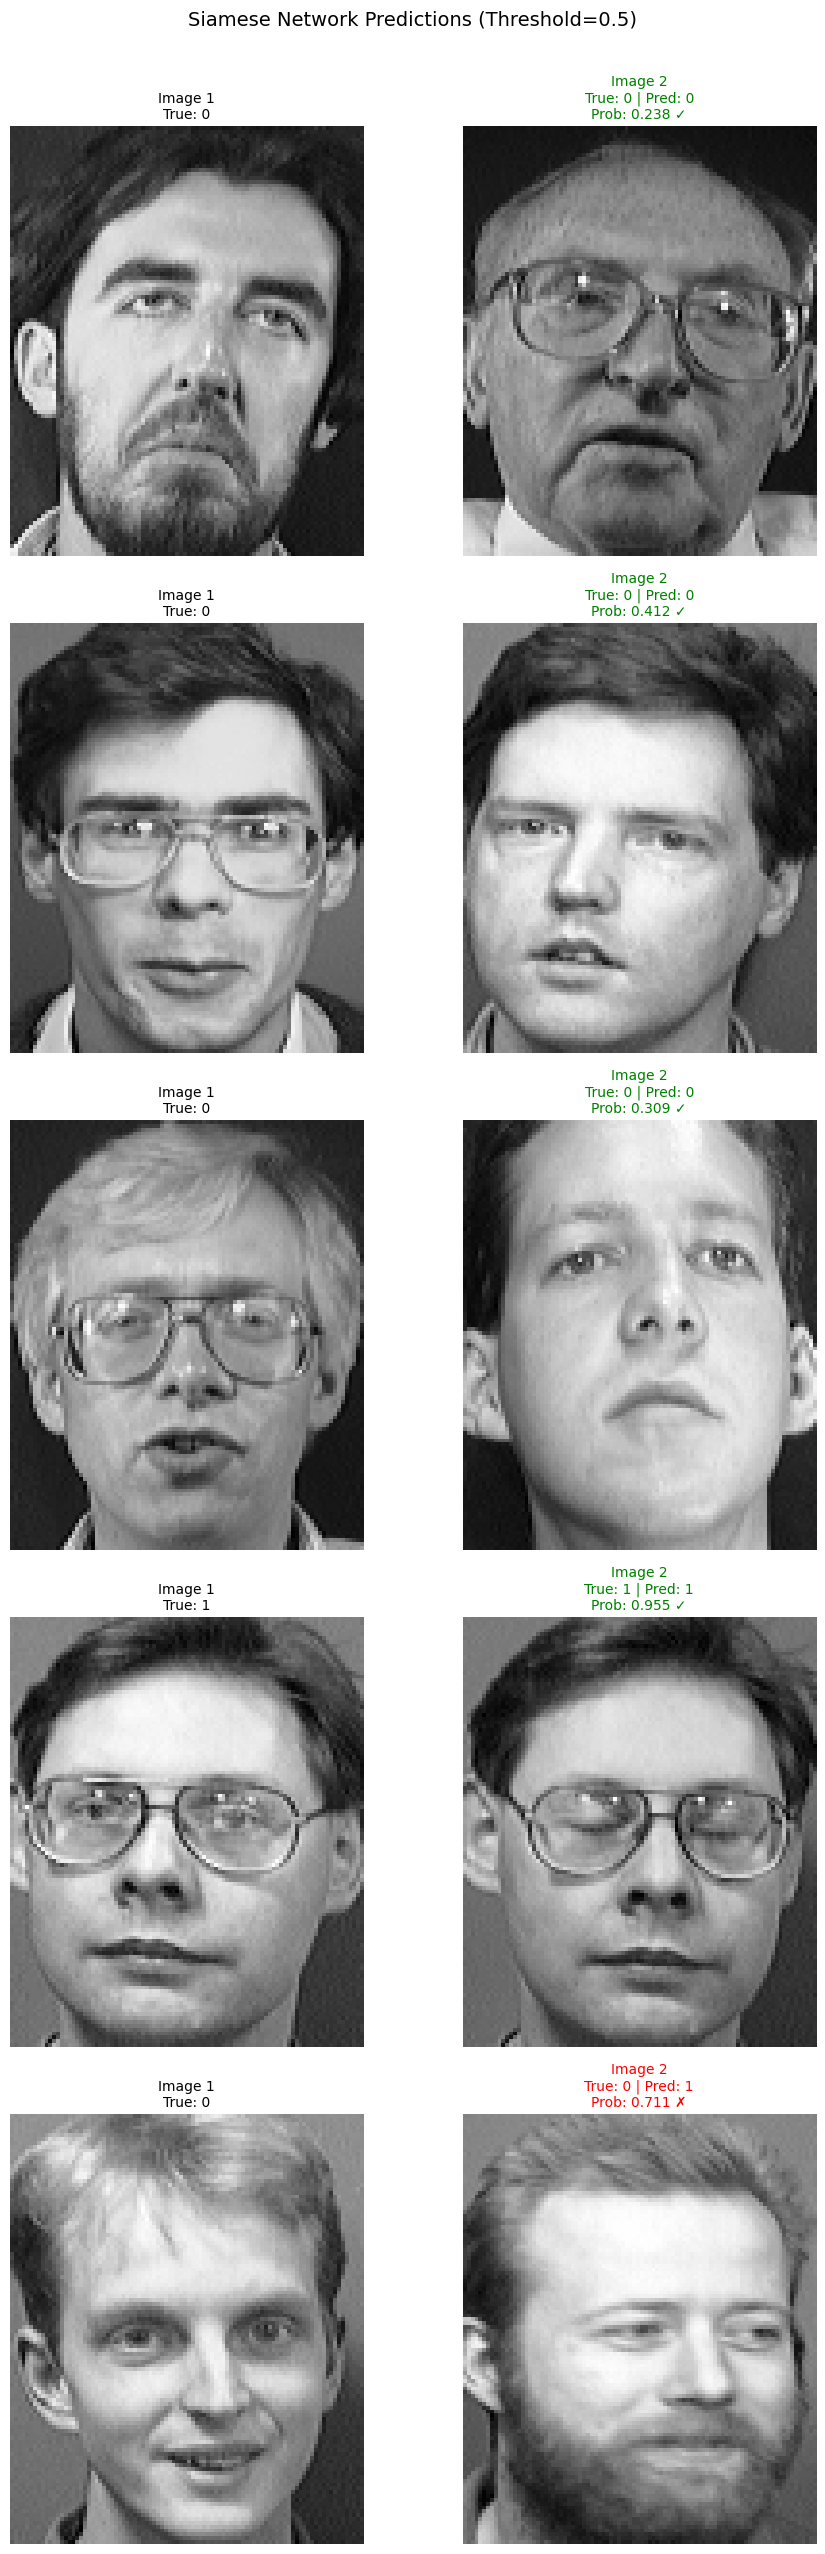

In [12]:
visualize_pairs(val_loader=val_loader, model=model, device=device, num_pairs=5)

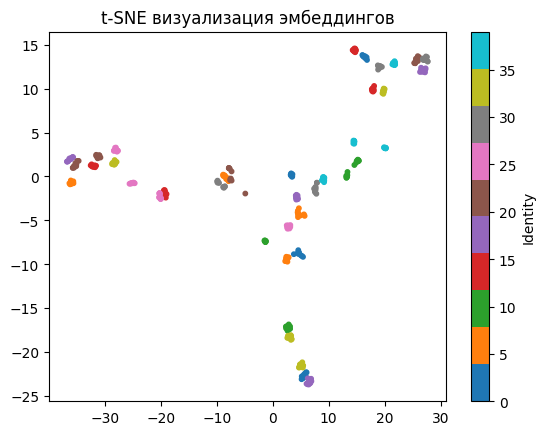

In [13]:
from sklearn.manifold import TSNE
import numpy as np

model.eval()
embeddings = []
labels_true = []

with torch.no_grad():
    for img, label in tsne_loader:
        img = img.to(device)
        emb = model.seq(img)
        embeddings.append(emb.cpu().numpy())
        labels_true.extend(label.numpy())

embeddings = np.vstack(embeddings)
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels_true, cmap='tab10', s=10)
plt.colorbar(label='Identity')
plt.title('t-SNE визуализация эмбеддингов')
plt.show()

In [14]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=2.0):
        super().__init__()
        self.margin = margin
    
    def forward(self, emb1, emb2, y):
        distance = F.pairwise_distance(emb1, emb2)
        loss = y * distance**2 + (1 - y) * torch.clamp(self.margin - distance, min=0)**2
        return loss.mean()

In [21]:
criterion = ContrastiveLoss()
model_contrastive =  SiamNetModel().to(device)
opt = optim.Adam(model_contrastive.parameters(), lr=0.0001)

In [22]:
def train_step2() -> float:
    model_contrastive.train()

    
    running_loss = 0.
    for img1, img2, labels in train_loader:
        img1 = img1.to(device)
        img2 = img2.to(device)
        labels = labels.to(device)
        

        opt.zero_grad()

        emb1, emb2 = model_contrastive(img1, img2)
        
        loss = criterion(emb1, emb2, labels)

        loss.backward()

        opt.step()
        
        # Накапливаем статистику.
        running_loss += loss
    
    # Контекстный менеджер `torch.no_grad` позволяет отключить вычисление градиентов.
    # Вычисления, в которые входят обучаемые параметры, не имеющие отношения к сети повлияют на процесс обучения,
    # если для них будут накапливаться градиенты.
    # Экономия памяти.
    with torch.no_grad():
        train_loss = running_loss / len(train_loader)
    return train_loss.item()


def val_step2() -> Tuple[float, float]:
    model_contrastive.eval()

    correct_total = 0.
    running_loss = 0.

    with torch.no_grad():
        for img1,  img2, labels in val_loader:
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.to(device)

            emb1, emb2 = model_contrastive(img1, img2)


            loss = criterion(emb1, emb2, labels)
            running_loss += loss
            
            distance = F.pairwise_distance(emb1, emb2)
            threshold = 0.5
            predictions = (distance < threshold).float()
            correct_total += (predictions == labels).sum()
        
    valid_loss = running_loss / len(val_loader)
    accuracy = correct_total / len(val_loader.dataset)
    return valid_loss.item(), accuracy.item()

In [23]:
contrastive_train_losses = []
contrastive_val_losses = []
contrastive_val_accs = []

model_contrastive.to(device)

epochs = 20

for _ in (pbar := tqdm(range(epochs))):
    train_loss = train_step2()
    valid_loss, valid_acc = val_step2()
    
    contrastive_train_losses.append(train_loss)
    contrastive_val_losses.append(valid_loss)
    contrastive_val_accs.append(valid_acc)
    
    pbar.set_description(f'Avg. train/valid loss/valid acc: {train_loss:.4f}/{valid_loss:.4f}/{valid_acc:.4f}')

Avg. train/valid loss/valid acc: 0.1946/0.2098/0.9995: 100%|██████████| 20/20 [02:40<00:00,  8.02s/it]


Text(0, 0.5, 'Loss')

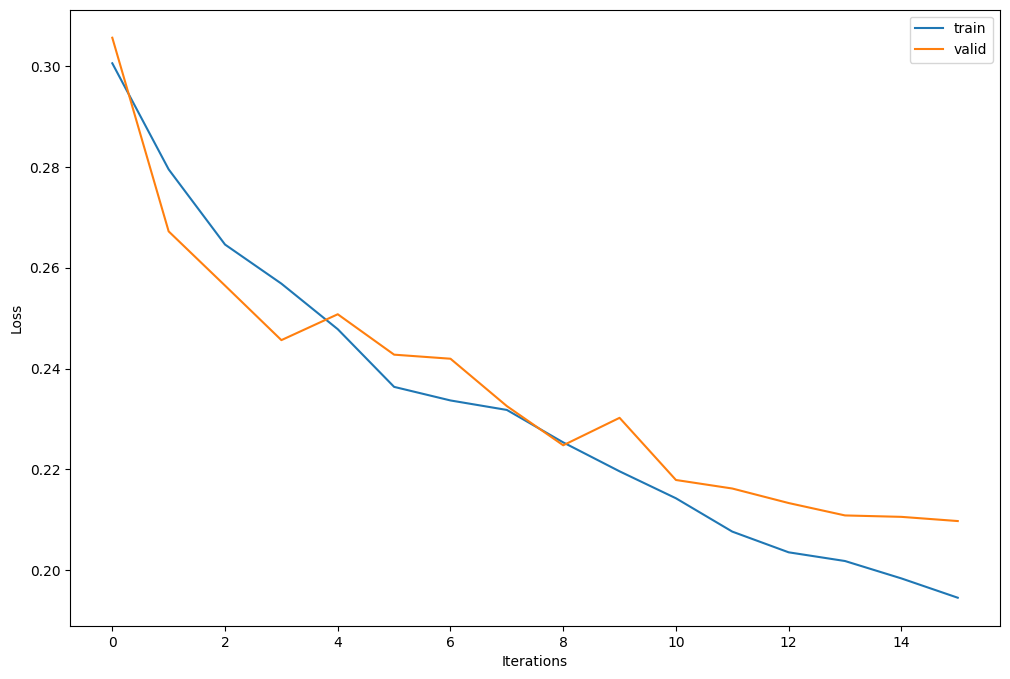

In [24]:
fig = plt.figure(figsize=(12, 8))

plt.plot(contrastive_train_losses[4:], label='train')
plt.plot(contrastive_val_losses[4:], label='valid')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')

Text(0, 0.5, 'Accuracy')

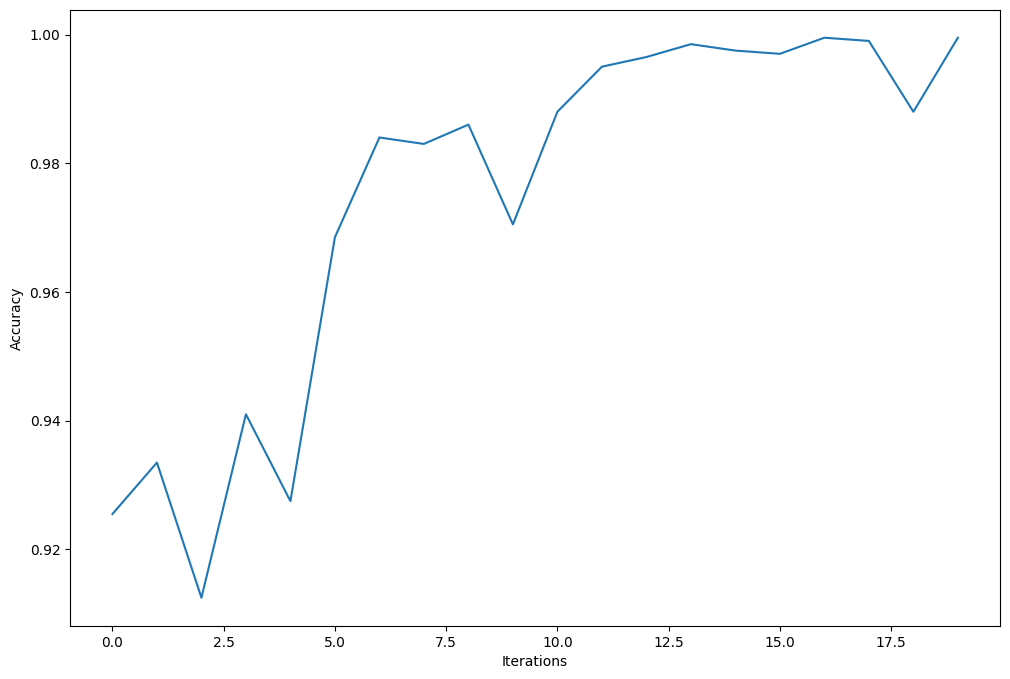

In [25]:
fig = plt.figure(figsize=(12, 8))

plt.plot(contrastive_val_accs)
plt.xlabel('Iterations')
plt.ylabel('Accuracy')

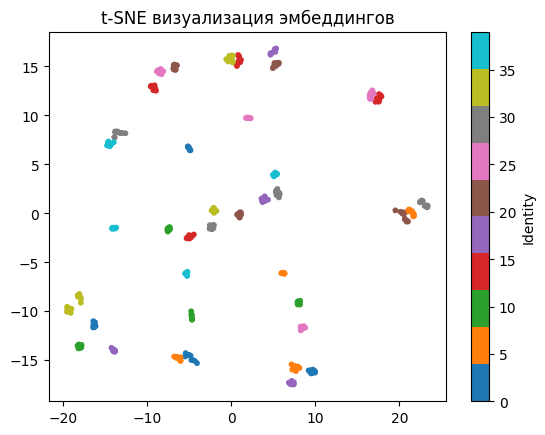

In [26]:

model_contrastive.eval()
embeddings = []
labels_true = []

with torch.no_grad():
    for img, label in tsne_loader:
        img = img.to(device)
        emb = model_contrastive.seq(img)
        embeddings.append(emb.cpu().numpy())
        labels_true.extend(label.numpy())

embeddings = np.vstack(embeddings)
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels_true, cmap='tab10', s=10)
plt.colorbar(label='Identity')
plt.title('t-SNE визуализация эмбеддингов')
plt.show()